# Chapter 4 - Analysis Notebook

Reproduces every figure and in-text statistic in **Chapter 4: Anatomy of the Autism Increase**.

Inputs: `idea_db_v2.sqlite`. Outputs: PNG figures in `figures/`. Run top-to-bottom; no network required.

All autism figures use the school-age band (6-21) and express counts as a rate per 1,000 enrolled, so a rise in the count is not confounded with enrollment growth. CDC ADDM benchmark values are external constants entered by hand (cited in the chapter text).

In [1]:
import sqlite3, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DB = '../_shared/idea_db_v2.sqlite'
FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)
con = sqlite3.connect(DB)
def q(sql, params=()):
    return pd.read_sql_query(sql, con, params=params)
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

## 1. State-year autism prevalence per 1,000 (6-21)

In [2]:
df = q('''
  SELECT d.school_year AS sy, d.state_code AS st, d.n_students AS aut, e.n_total AS enr
  FROM fact_state_disability d
  JOIN fact_state_enrollment e
    ON d.school_year=e.school_year AND d.state_code=e.state_code
  WHERE d.disability_code='AUT' AND d.age_band='6-21' AND d.n_students IS NOT NULL''')
df['per1000'] = 1000.0 * df['aut'] / df['enr']
nat = df.groupby('sy').apply(lambda x: 1000.0*x['aut'].sum()/x['enr'].sum())
years = list(nat.index)
nat.round(2)

sy
2005-06     3.92
2006-07     4.53
2007-08     5.21
2008-09     5.92
2009-10     6.71
2010-11     7.44
2011-12     8.17
2012-13     8.85
2013-14     9.51
2014-15    10.15
2015-16    10.82
2016-17    11.53
2017-18    12.33
2018-19    13.21
2019-20    14.13
2020-21    15.81
2021-22    16.78
2022-23    18.33
2023-24    20.28
dtype: float64

## 2. Administrative vs epidemiological prevalence (Figure 4.1)

The IDEA administrative rate (this dataset) plotted against CDC ADDM 8-year-old estimates. ADDM points are external benchmarks: 1/68 (2012), ~1/54 (2016), 1/44 (2018), 1/36 (2020), ~1/31 (2022), converted to per-1,000 and placed at the matching school year.

IDEA national per-1,000: 3.9 (2005-06) -> 20.3 (2023-24); multiple 5.2x


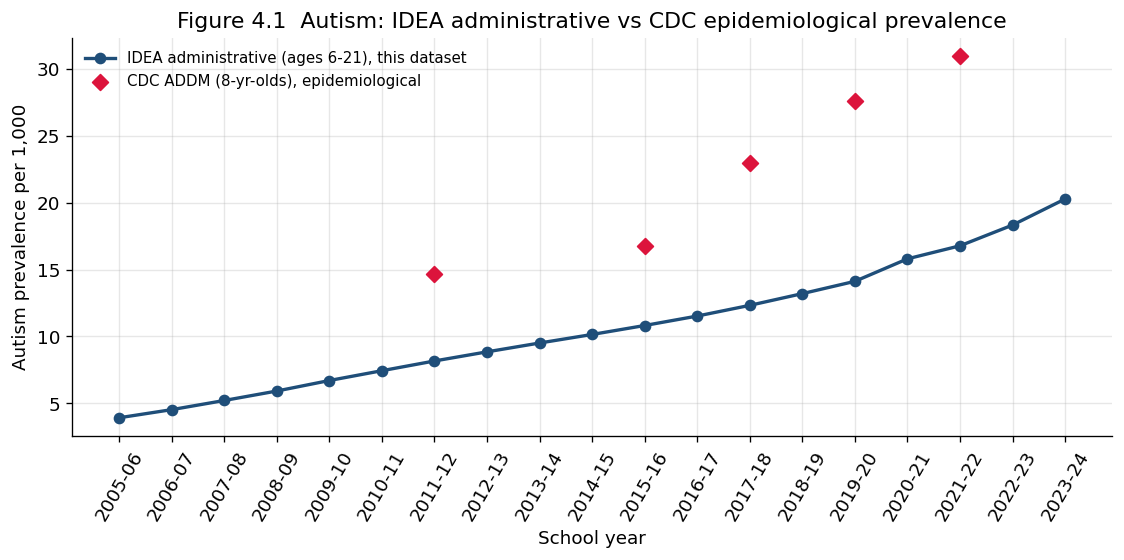

In [3]:
fig, ax = plt.subplots(figsize=(9.5,4.8))
ax.plot(years, nat.values, marker='o', color='#1f4e79', lw=2,
        label='IDEA administrative (ages 6-21), this dataset')
cdc = {'2011-12':14.7, '2015-16':16.8, '2017-18':23.0, '2019-20':27.6, '2021-22':31.0}
ax.scatter(list(cdc), list(cdc.values()), color='crimson', marker='D', s=45, zorder=5,
           label='CDC ADDM (8-yr-olds), epidemiological')
ax.set_ylabel('Autism prevalence per 1,000'); ax.set_xlabel('School year')
ax.tick_params(axis='x', rotation=60); ax.legend(frameon=False, fontsize=9)
ax.set_title('Figure 4.1  Autism: IDEA administrative vs CDC epidemiological prevalence')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig4_1_prevalence_benchmark.png', bbox_inches='tight')
print(f'IDEA national per-1,000: {nat.iloc[0]:.1f} ({years[0]}) -> {nat.iloc[-1]:.1f} ({years[-1]}); multiple {nat.iloc[-1]/nat.iloc[0]:.1f}x')

## 3. State dispersion over time (Figure 4.2) and dispersion statistics

,min,median,max,max_min_ratio,CV
sy,,,,,
2005-06,1.51,3.29,8.88,5.87,0.41
2014-15,1.28,9.16,18.14,14.15,0.33
2023-24,8.30,18.11,30.23,3.64,0.26


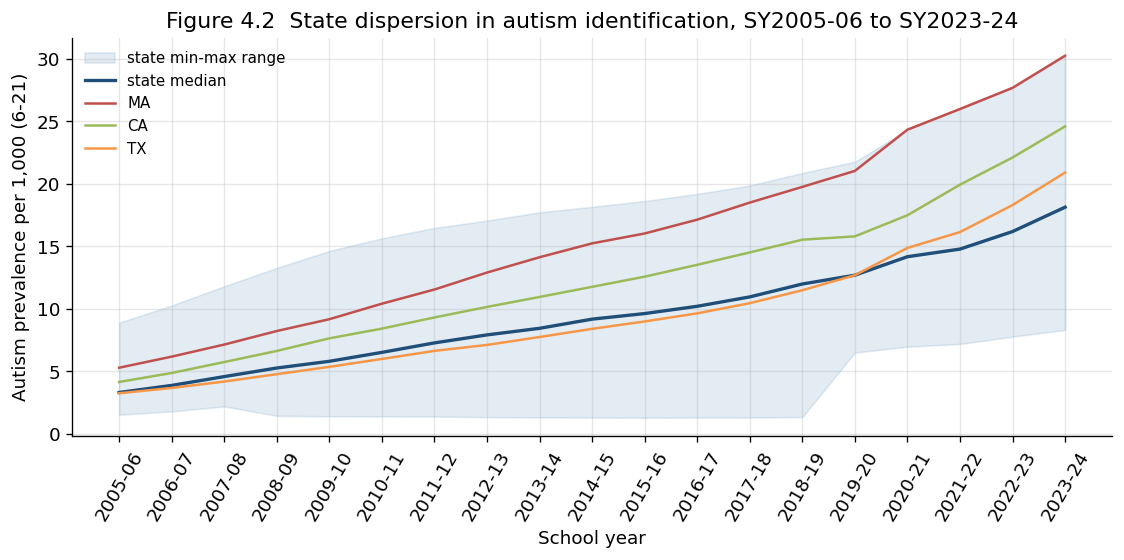

In [4]:
piv = df.pivot(index='sy', columns='st', values='per1000')
fig, ax = plt.subplots(figsize=(9.5,4.8))
ax.fill_between(years, piv.min(axis=1), piv.max(axis=1), alpha=0.15, color='steelblue', label='state min-max range')
ax.plot(years, piv.median(axis=1), color='#1f4e79', lw=2, label='state median')
for st,col in [('MA','#c0504d'),('CA','#9bbb59'),('TX','#f79646')]:
    if st in piv: ax.plot(years, piv[st], lw=1.5, label=st, color=col)
ax.set_ylabel('Autism prevalence per 1,000 (6-21)'); ax.set_xlabel('School year')
ax.tick_params(axis='x', rotation=60); ax.legend(frameon=False, fontsize=9)
ax.set_title('Figure 4.2  State dispersion in autism identification, SY2005-06 to SY2023-24')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig4_2_state_dispersion.png', bbox_inches='tight')

disp = pd.DataFrame({
    'min': piv.min(axis=1), 'median': piv.median(axis=1), 'max': piv.max(axis=1),
    'max_min_ratio': piv.max(axis=1)/piv.min(axis=1),
    'CV': piv.std(axis=1)/piv.mean(axis=1),
}).loc[['2005-06','2014-15','2023-24']]
disp.round(2)

## 4. Ranked states, SY2023-24 (Figure 4.3, Table 4.1 inputs)

,st,per1000
929,MT,8.3
921,LA,10.6
919,KS,12.1
946,UT,12.4
952,WY,12.5
934,NY,26.0
922,ME,26.4
940,PA,27.7
926,MN,28.1
924,MA,30.2


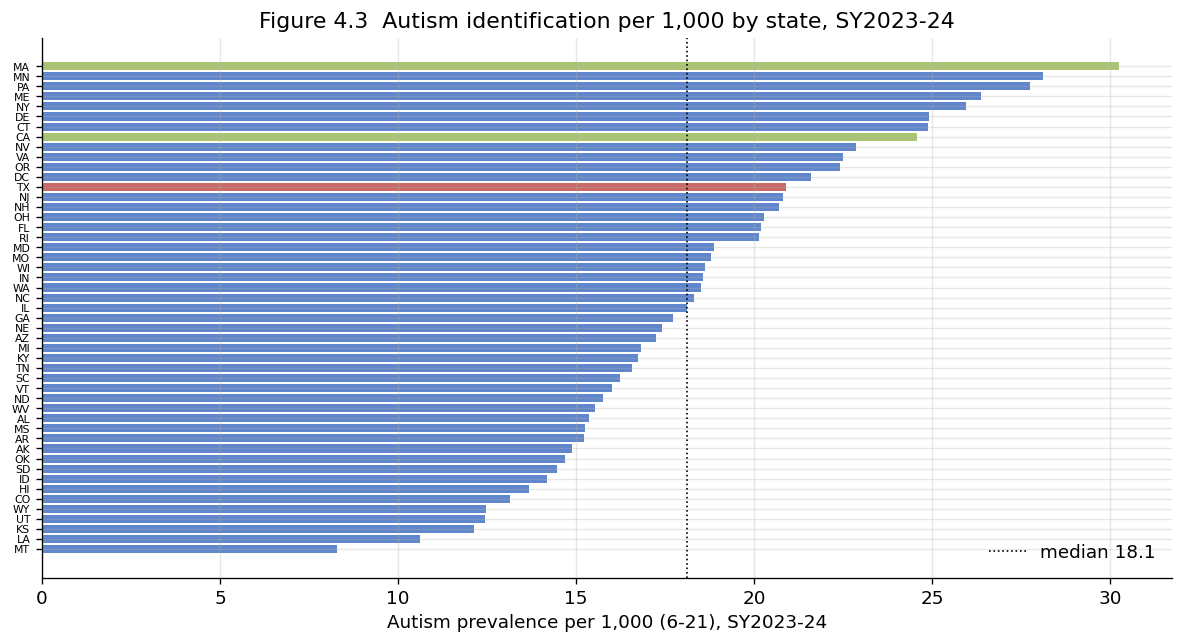

In [5]:
last = df[df['sy']=='2023-24'].sort_values('per1000')
fig, ax = plt.subplots(figsize=(10,5.5))
colors = ['#c0504d' if s=='TX' else ('#9bbb59' if s in ('MA','CA') else '#4472c4') for s in last['st']]
ax.barh(last['st'], last['per1000'], color=colors, alpha=0.85)
ax.axvline(last['per1000'].median(), color='black', ls=':', lw=1, label=f"median {last['per1000'].median():.1f}")
ax.set_xlabel('Autism prevalence per 1,000 (6-21), SY2023-24'); ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=6.5); ax.legend(frameon=False)
ax.set_title('Figure 4.3  Autism identification per 1,000 by state, SY2023-24')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig4_3_state_ranked.png', bbox_inches='tight')
pd.concat([last.head(5)[['st','per1000']], last.tail(5)[['st','per1000']]]).round(1)

In [6]:
con.close()
print('Chapter 4 figures written to', FIGDIR)

Chapter 4 figures written to figures
